# ML from DFT data

- [ ] learn on separated FM and NM AGAIN
- [ ] remove high order BOP features before learing
- [ ] Recursive Feature elimination after removing high order features
- [ ] make recursion on bond energy
- [ ] change OS to 1/10,
- [ ] 1/10 OS and scf bop
- learn form library features
- compare different regression methods
   - Linear regression
   - add SVM
   - kernel methods
   - Gaussian process.
- compare different test-train splittings
- Learn on increasing domain knowledge

 - input: clean features dataframes from pickles
 - output : plots and Models

In [1]:
from Tools.DatasetTools.Commoms import *

In [2]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=22)
from matplotlib.lines import Line2D

# Parameters 

In [3]:
from Tools.DatasetTools.DatasetOperator import Dataset, DatasetTester

In [4]:
DS = Dataset('Fe-Mo')

# Targets

Text(0.5, 0, '$V_0$')

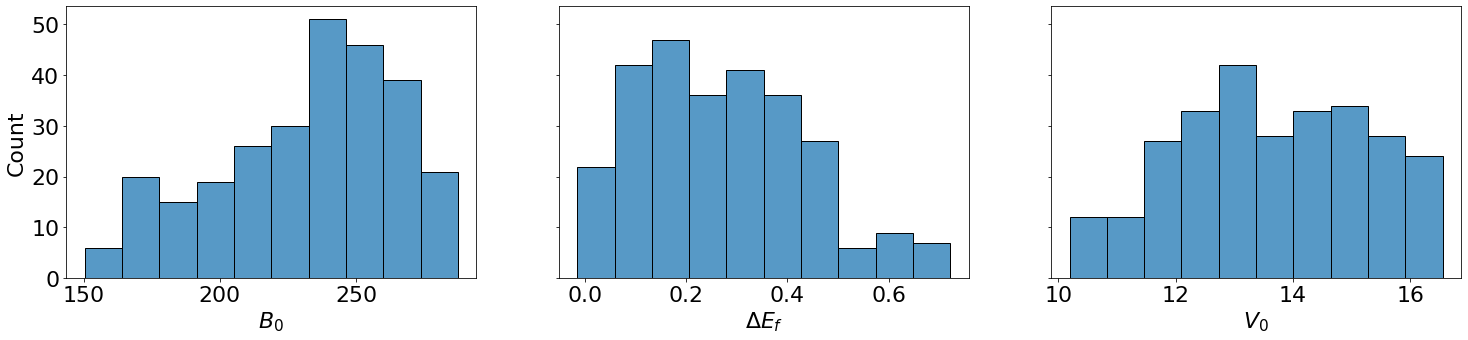

In [5]:
fig, ax = plt.subplots(1,3, figsize=(25, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0])
sns.histplot( DS.BS['EF'], ax= ax[1])
sns.histplot( DS.BS['V0'], ax= ax[2])
ax[0].set_xlabel('$B_0$')
ax[1].set_xlabel('$\Delta E_f$')
ax[2].set_xlabel('$V_0$')

# Machine Learning 

In [6]:
from Tools.DatasetTools.MLConveniences import *

In [7]:
resultslocation = DS.resultslocation

## Feature sets

In [8]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [9]:
Features['Canonical BOP']

,Structure,Mag,U_bind,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_1_0,...,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16,random
Fe_pv8Mo_sv22.sigma-BBABB.FM,10,0,-100.702297,-7.906327,-1.428383,0.000000,-6.005237,-0.472706,0.000000,1.174563,...,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000,0.955433
Fe_pv10Mo_sv20.sigma-ABBAB.FM,10,0,-78.594335,-7.771059,-1.424594,0.000000,-5.906606,-0.439859,0.000000,1.201761,...,0.668575,0.166260,0.000000,1.224174,1.311938,0.000000,1.187308,1.155463,0.000000,0.439709
Fe_pv4Mo_sv20.C36-ABBBB.FM,3,0,-94.449166,-8.534487,-7.595698,0.000000,0.000000,0.000000,-0.938789,1.303069,...,0.000000,0.000000,0.501537,1.081732,1.156282,0.000000,0.000000,0.000000,0.901327,0.435300
Fe_pv5Mo_sv24.chi-AABB.FM,6,0,-116.205661,-8.244366,-6.070495,-1.652565,0.000000,0.000000,-0.521305,1.162619,...,0.000000,0.000000,0.186186,1.251703,1.437268,1.179083,0.000000,0.000000,1.006205,0.573144
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,4,1,-121.105805,-8.136275,-2.533063,0.000000,-0.844603,-0.318349,-4.440260,1.218738,...,0.256809,0.124851,0.170809,1.192249,1.343509,0.000000,1.139857,0.956735,0.947607,0.432065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,9,1,-40.035290,-8.020136,-2.520056,0.000000,-0.663807,-0.397166,-4.439107,1.265062,...,0.220371,0.224323,0.222761,1.071111,1.222567,0.000000,0.902499,0.748344,1.001884,0.411660
Fe_pv8Mo_sv22.sigma-BBABB.NM,10,1,-100.702297,-7.906327,-1.428383,0.000000,-6.005237,-0.472706,0.000000,1.174563,...,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000,0.336530
Fe_pv1Mo_sv3.L12-AB3.FM,7,0,-12.617373,-6.832601,-6.832601,0.000000,0.000000,0.000000,0.000000,1.063750,...,0.000000,0.000000,0.000000,1.140024,1.140024,0.000000,0.000000,0.000000,0.000000,0.633735
Fe_pv8Mo_sv22.sigma-BBBBA.FM,10,0,-94.569986,-7.892530,-5.305761,0.000000,-2.136368,-0.450401,0.000000,1.174563,...,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000,0.520255


In [10]:
Features.keys()

dict_keys(['atomic', 'dataset', 'Pyscal', 'Canonical BOP', 'Projections BOP', 'Projections OS BOP', 'Projections sOS BOP', 'dataset + Canonical BOP', 'dataset + Projections BOP', 'dataset + Projections OS BOP', 'dataset + Projections sOS BOP'])

## BOP features with and without CP averages

In [11]:
def clean_CNAVS(name:str, features:pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_CN)')
    else:
        return features

In [12]:
def clean_zeros(name:str, features:pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_0$)')
    else:
        return features

In [13]:
def notyetclean(name:str):
    return ('BOP' in name) and ('CNAV' not in name) and ('Zeros' not in name)

In [14]:
Features.update({name+' no CNAV': clean_CNAVS(name, features) for name, features in Features.items() if notyetclean(name) } )

In [15]:
# Features.update({name+' no Zeros': clean_zeros(name, features) for name, features in Features.items() if notyetclean(name)} )

## test - train splits

In [16]:
samplesplit = DS.get_samplesplit()

# Models: adjust params

In [17]:
Models = {
    'Kernel Ridge': Pipeline([('scaler', StandardScaler()), ('regressor', KernelRidge())]),
}

In [18]:
Parameters = {
    'Kernel Ridge': {'regressor__alpha':[0.1, 0.01,0.001, 1e-4],
                     'regressor__kernel':['rbf', 'polynomial'], 
                     'regressor__degree': [4,5,6,7],
                     'regressor__coef0': [0, 1, 10],
                    }
}

In [19]:
samplefolds = list(DS.get_folds())

# fits

In [20]:
Models

{'Kernel Ridge': Pipeline(steps=[('scaler', StandardScaler()), ('regressor', KernelRidge())])}

In [21]:
fittedmodelslocation = os.path.join(DS.resultslocation, 'KRR_FittedCVSearch.pkl')

In [22]:
if os.path.exists(fittedmodelslocation):
    with open(fittedmodelslocation, 'rb') as pkl:
        FittedModels = pickle.load(pkl)

In [23]:
FittedModels = {}

In [24]:
for name, model in Models.items():
    print (name)
    progress = tqdm(Features.items())
    for key, features in progress: #Features.items():
        if 'no CNAV' in key:
            continue
        if (name, key) in FittedModels.keys():
            continue
        model = GridSearchCV(
            Models[name],
            Parameters[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            verbose = 1,
            return_train_score= True,
        )
        FittedModels[(name, key)] = model.fit(features, DS.target)

Kernel Ridge


  0%|          | 0/19 [00:00<?, ?it/s]

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits


In [25]:
with open(fittedmodelslocation, 'wb') as pkl:
    pickle.dump(FittedModels, pkl)

In [26]:
best_scores = {}
for (modelname, featurename), fittedmodel in FittedModels.items():
    best_scores[(modelname, featurename)] = {'test': abs(fittedmodel.best_score_)}
best_scores = pd.DataFrame.from_dict(best_scores, orient='index')
best_scores.index = pd.MultiIndex.from_tuples(best_scores.index)
best_scores.sort_values(by='test', ascending=True, inplace=True)
best_scores.sort_index(level=0, sort_remaining=False, ascending=True, inplace=True)

In [27]:
best_scores.idxmin()

test    (Kernel Ridge, dataset + Projections OS BOP)
dtype: object

In [28]:
best_combi = best_scores.idxmin()['test']

In [29]:
best_combi

('Kernel Ridge', 'dataset + Projections OS BOP')

In [30]:
results = pd.DataFrame.from_dict(FittedModels[best_combi].cv_results_)

In [31]:
results.sort_values(by='mean_test_score', ascending=False, inplace=True)

In [32]:
best_scores.loc[best_combi]

test    0.037122
Name: (Kernel Ridge, dataset + Projections OS BOP), dtype: float64

In [33]:
results.loc[7].params

{'regressor__alpha': 0.1,
 'regressor__coef0': 0,
 'regressor__degree': 7,
 'regressor__kernel': 'polynomial'}

In [34]:
for parameters in Parameters.values():
    for key in parameters.keys():
        print (results.groupby(by='param_'+key)['mean_test_score'].max())

param_regressor__alpha
0.0001   -0.041152
0.0010   -0.040366
0.0100   -0.038317
0.1000   -0.037122
Name: mean_test_score, dtype: float64
param_regressor__kernel
polynomial   -0.037122
rbf          -0.057806
Name: mean_test_score, dtype: float64
param_regressor__degree
4   -0.037866
5   -0.037122
6   -0.037577
7   -0.039100
Name: mean_test_score, dtype: float64
param_regressor__coef0
0    -0.057806
1    -0.037122
10   -0.051087
Name: mean_test_score, dtype: float64


In [35]:
FittedModels[best_combi].best_params_

{'regressor__alpha': 0.1,
 'regressor__coef0': 1,
 'regressor__degree': 5,
 'regressor__kernel': 'polynomial'}

(0.0, 0.1)

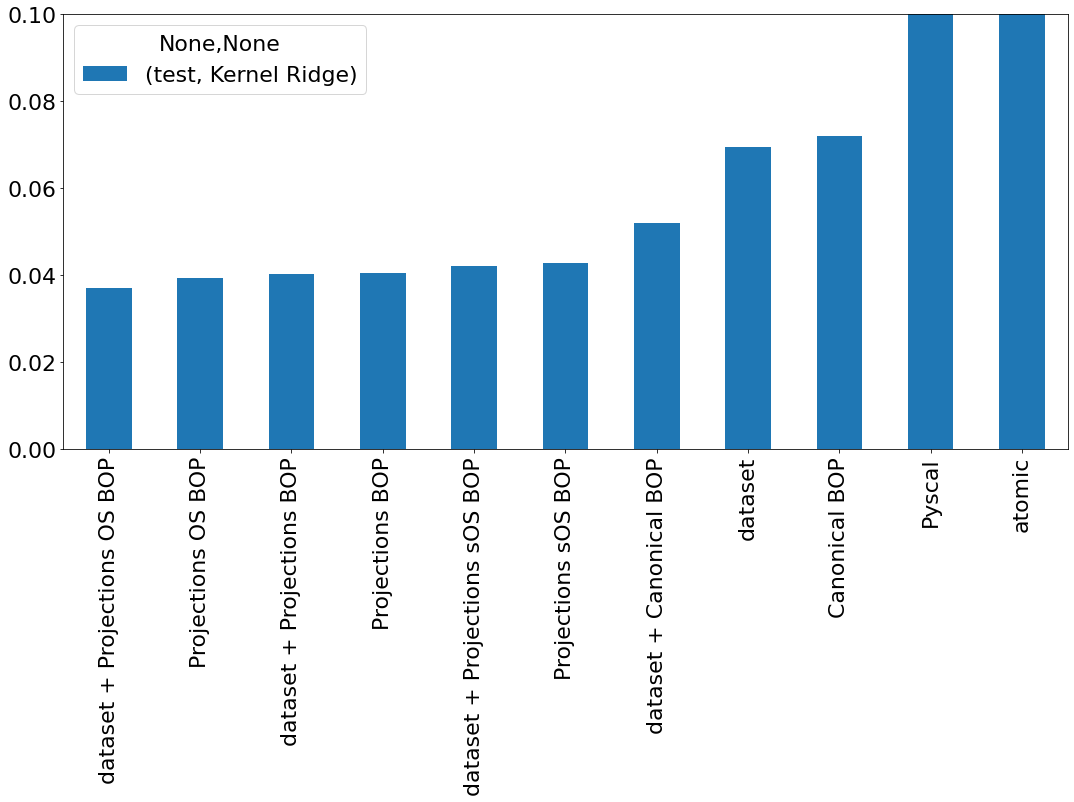

In [36]:
ax = best_scores.unstack(level=0).sort_values(by=('test','Kernel Ridge')).plot.bar()
ax.set_ylim([0,0.1])


# Recursivity

In [37]:
Tester = DatasetTester()

In [38]:
from importlib.machinery import SourceFileLoader
Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
#from Tools.DatasetTools.DatasetOperator import Dataset
#DS = SourceFileLoader('DS', 'Tools/DatasetTools/DatasetOperator.py').load_module().Dataset('Fe-Mo')
#Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
#samplesplit = DS.get_samplesplit()

In [39]:
import copy

In [40]:
RecursivityModels = copy.deepcopy(FittedModels)

In [41]:
test_scores = Tester.make_recursivity_anbn(DS, RecursivityModels, {'includemag':False})

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Tools/DatasetTools/DatasetOperator.py:220: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  axes.plot(


(<Figure size 1296x576 with 1 Axes>,
 <AxesSubplot:xlabel='number of features', ylabel='test RMSE @ $\\Delta E_f$'>)

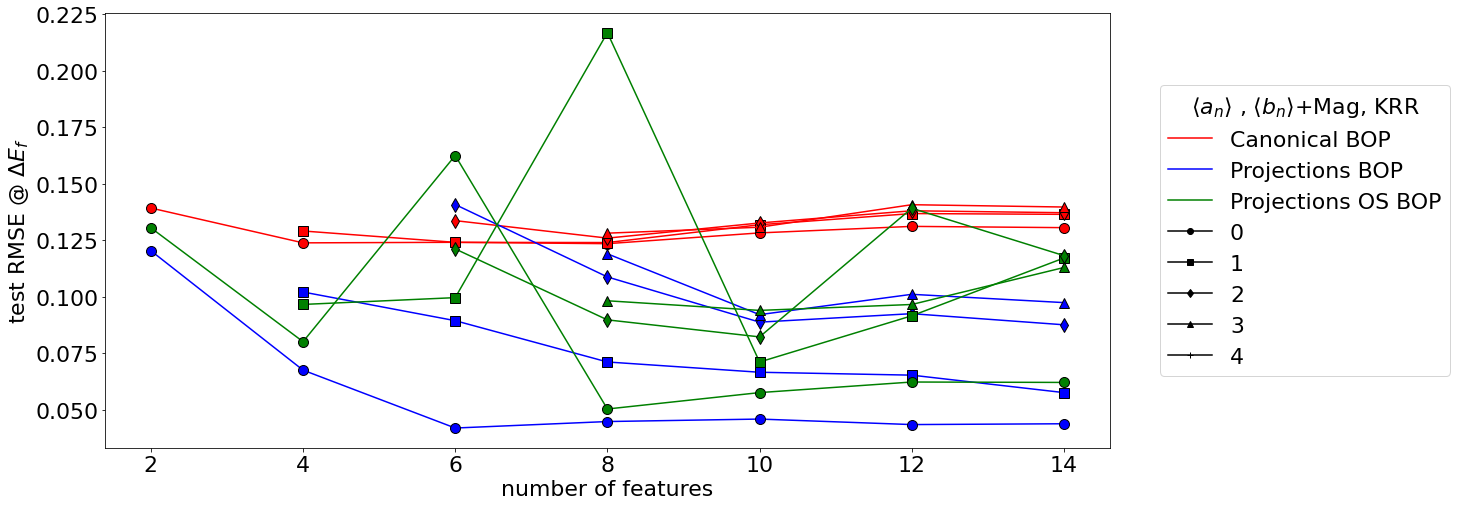

In [42]:
Tester.plot_recursivity_curve(test_scores, 'Kernel Ridge', )

In [43]:
fig.savefig(f'{DS.dataset}/graphs/KRR_recursivity_anbn.pdf', bbox_inches='tight')

# Fits on reduced features 

In [236]:
ReducedFittedModels = {}

In [237]:
for name, model in Models.items():
    print (name)
    progress = tqdm(Features.items())
    for key, features in progress: #Features.items():
        if 'no CNAV' in key:
            continue
        if (name, key) in ReducedFittedModels.keys():
            continue
        model = GridSearchCV(
            Models[name],
            Parameters[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            verbose = 1,
            return_train_score= True,
        )
        if 'BOP' in key :
            reducedfeatures = features.filter(regex='Structure|Mag|.*moments_[0-8]_.*|.*[ab]n_[0-5].*')
        else:
            reducedfeatures = features
        ReducedFittedModels[(name, key)] = model.fit(reducedfeatures, DS.target)

Kernel Ridge


  0%|          | 0/19 [00:00<?, ?it/s]

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Fitting 5 folds for each of 96 candidates, totalling 480 fits


In [240]:
best_scores_reduced = {}
for (modelname, featurename), fittedmodel in ReducedFittedModels.items():
    best_scores_reduced[(modelname, featurename)] = {'test': abs(fittedmodel.best_score_)}
best_scores_reduced = pd.DataFrame.from_dict(best_scores_reduced, orient='index')
best_scores_reduced.index = pd.MultiIndex.from_tuples(best_scores_reduced.index)
best_scores_reduced.sort_values(by='test', ascending=True, inplace=True)
best_scores_reduced.sort_index(level=0, sort_remaining=False, ascending=True, inplace=True)

(0.0, 0.1)

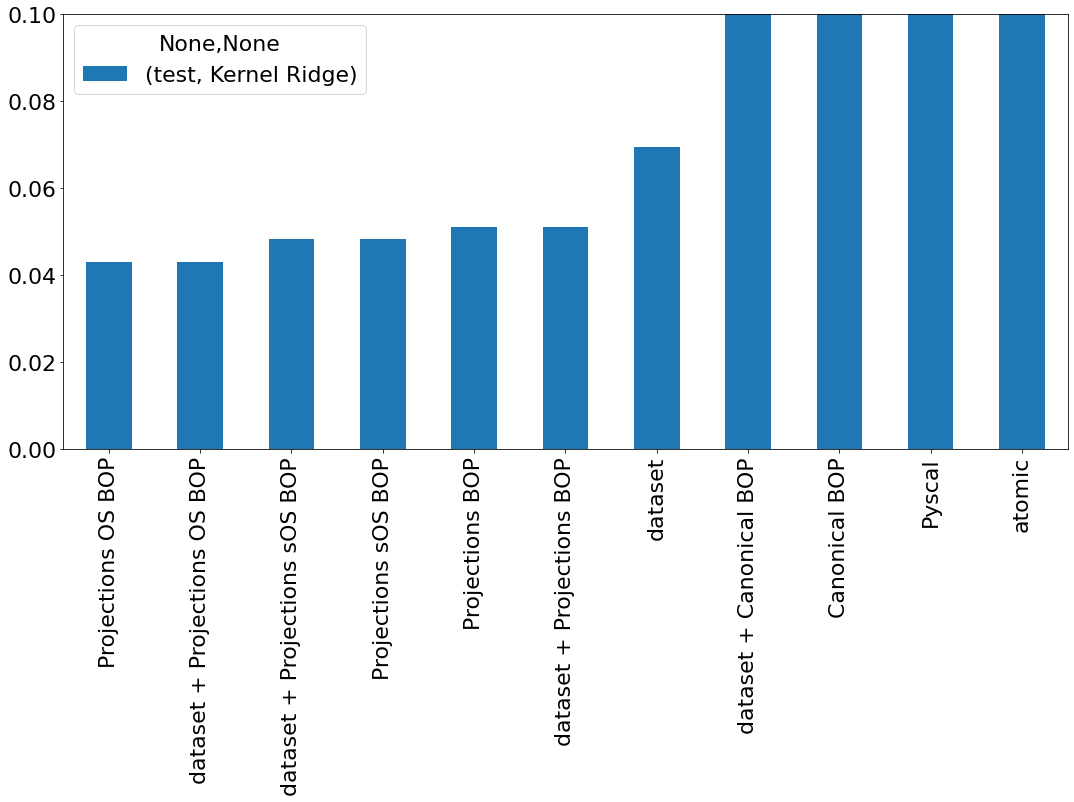

In [241]:
ax = best_scores_reduced.unstack(level=0).sort_values(by=('test','Kernel Ridge')).plot.bar()
ax.set_ylim([0,0.1])


In [218]:
best_scores_reduced

test
Kernel Ridge dataset + Projections OS BOP   0.037122
             Projections OS BOP             0.039410
             dataset + Projections BOP      0.040358
             Projections BOP                0.040572
             dataset + Projections sOS BOP  0.042194
             Projections sOS BOP            0.042764
             dataset + Canonical BOP        0.052098
             dataset                        0.069591
             Canonical BOP                  0.072036
             Pyscal                         0.170910
             atomic                         0.173327

# Feature Importances 

In [44]:
from sklearn.inspection import permutation_importance

In [45]:
def get_importances(estimator, features, target):
    allimportances = permutation_importance(estimator,features, target, scoring = 'neg_root_mean_squared_error', )
    importances = pd.DataFrame(data = allimportances['importances_mean'],columns=['importances_mean'], index = features.columns) #, 'importances_std']]
    importances.sort_values(by='importances_mean', inplace=True)
    return importances

In [46]:
importances = {}
for (modelname, name), estimator in FittedModels.items():
    print(name)
    allimportances = get_importances(estimator.best_estimator_ , DS.Features[name], DS.target)
    importances[(modelname, name)] =allimportances[allimportances['importances_mean']>=allimportances['importances_mean']['random']]

atomic
dataset
Pyscal
Canonical BOP
Projections BOP
Projections OS BOP
Projections sOS BOP
dataset + Canonical BOP
dataset + Projections BOP
dataset + Projections OS BOP
dataset + Projections sOS BOP


In [47]:
for (modelname, name),timportances in importances.items():
    timportances.sort_values(by='importances_mean', inplace=True)

/tmp/ipykernel_22699/1539084716.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timportances.sort_values(by='importances_mean', inplace=True)


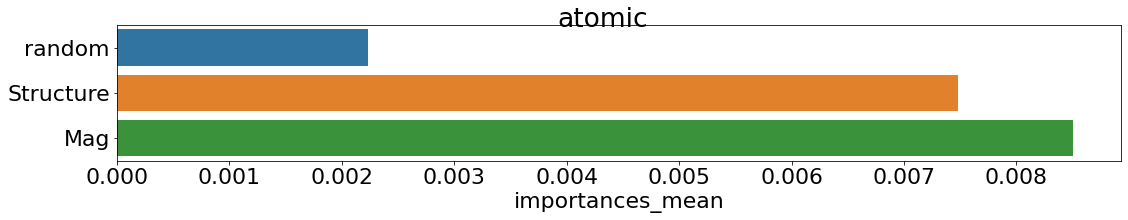

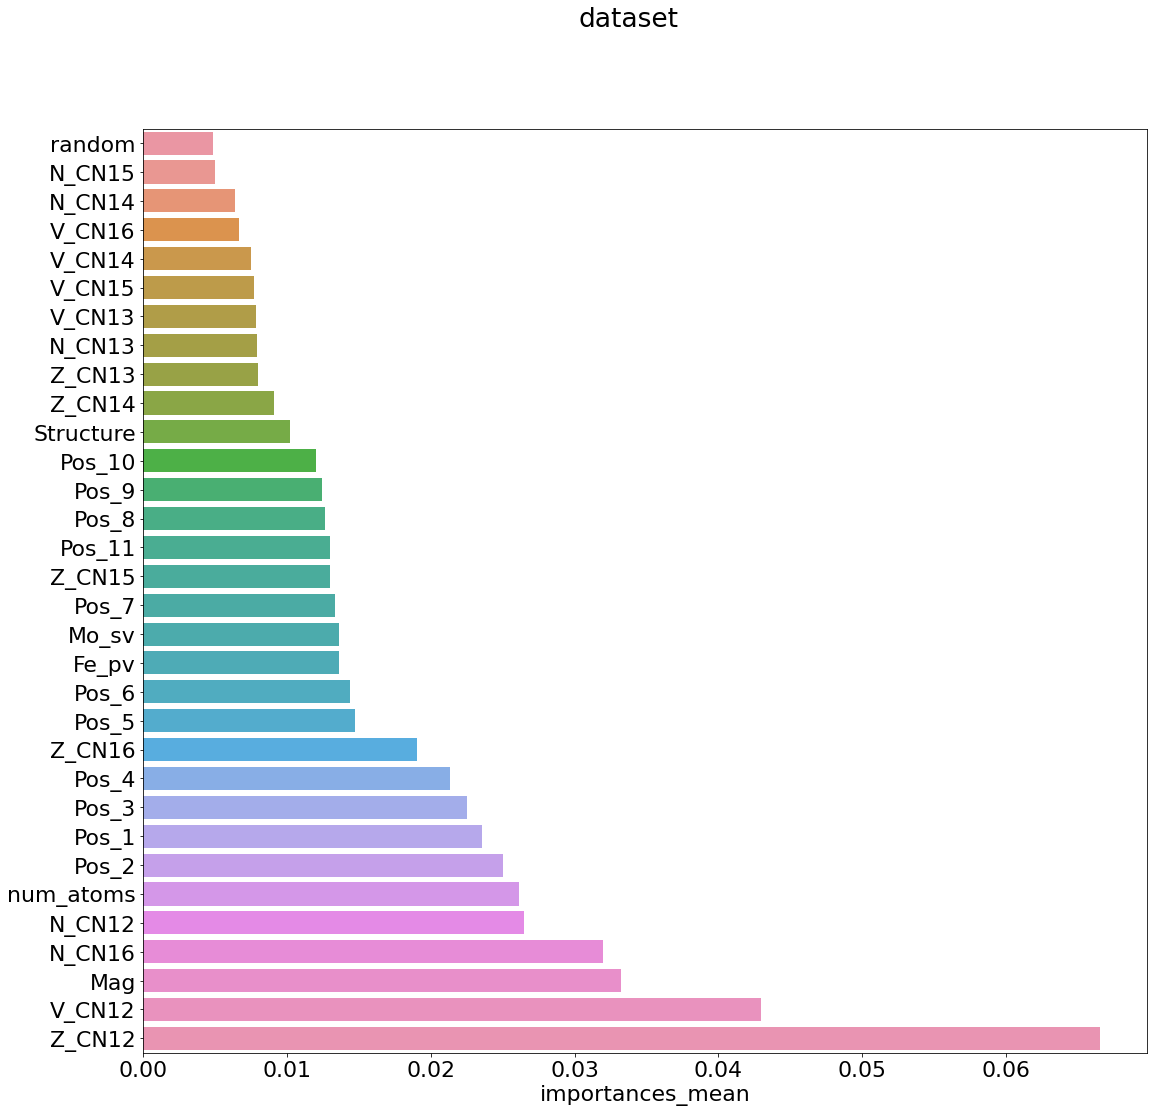

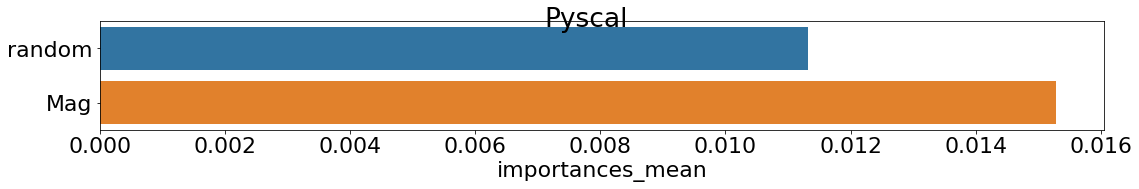

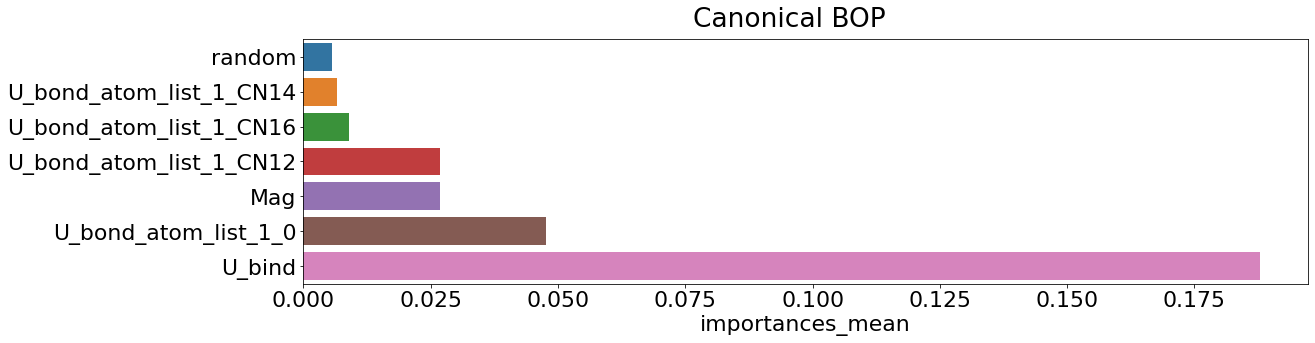

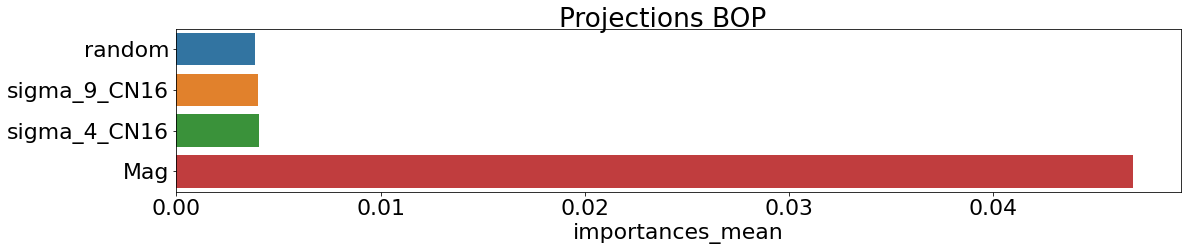

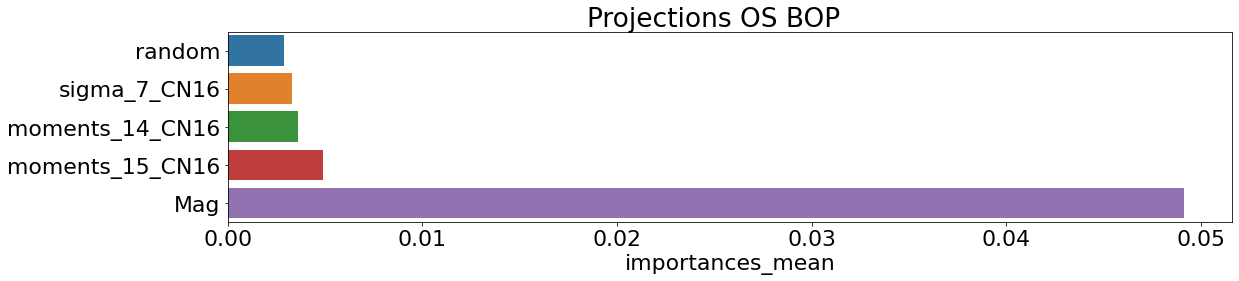

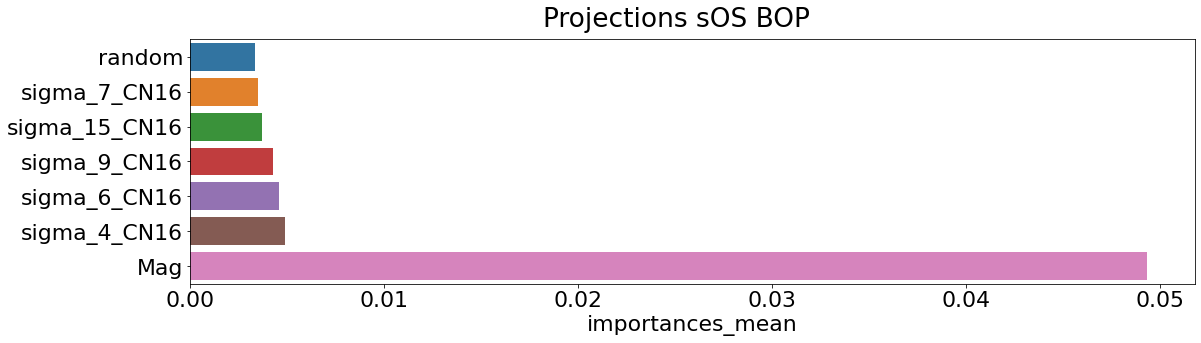

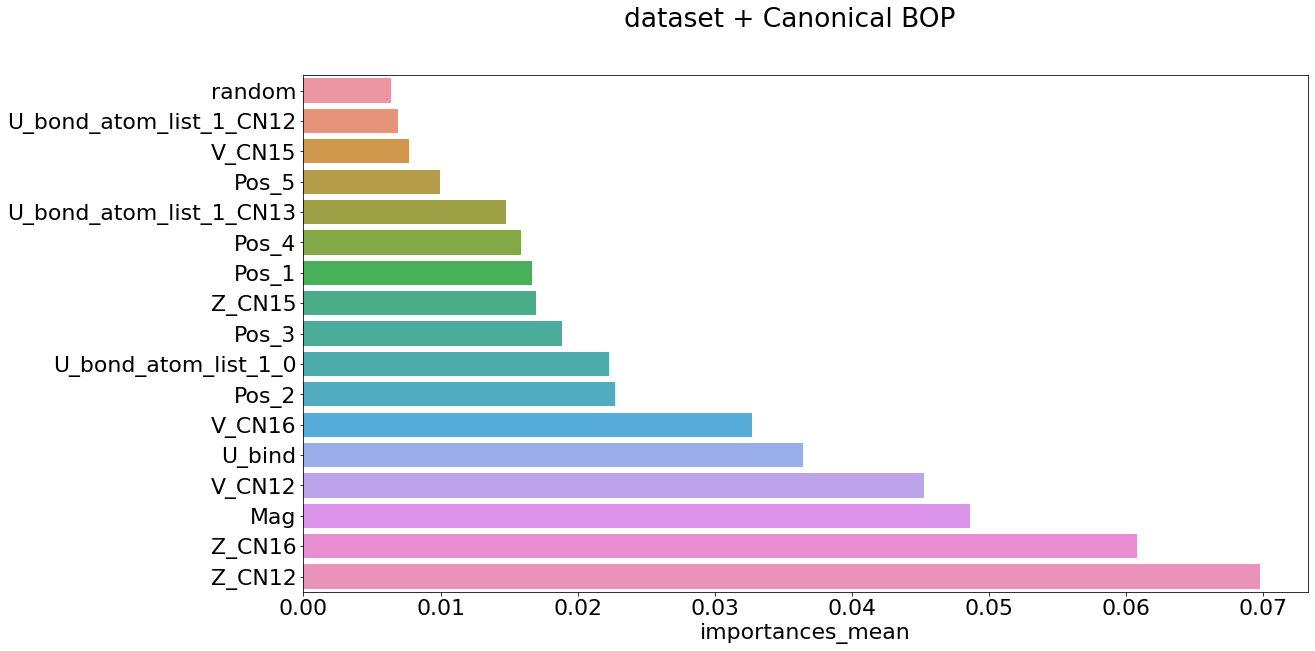

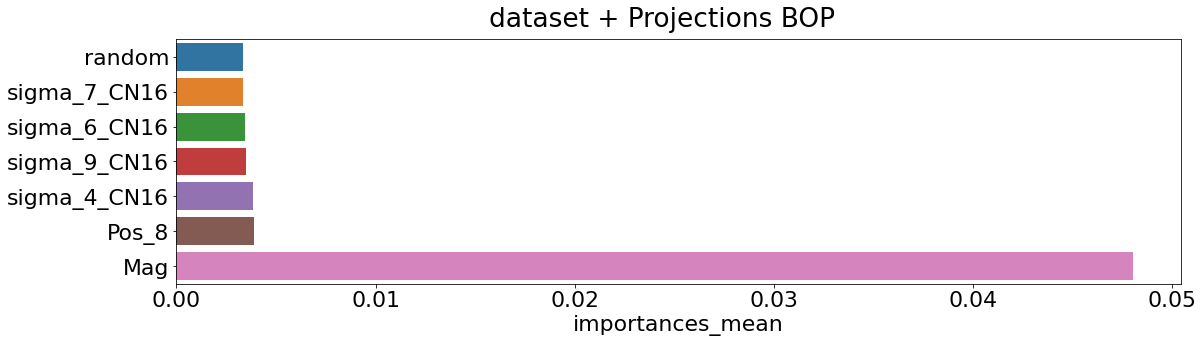

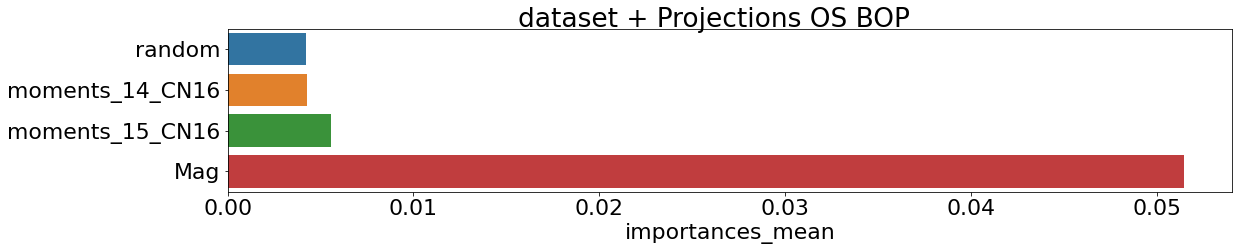

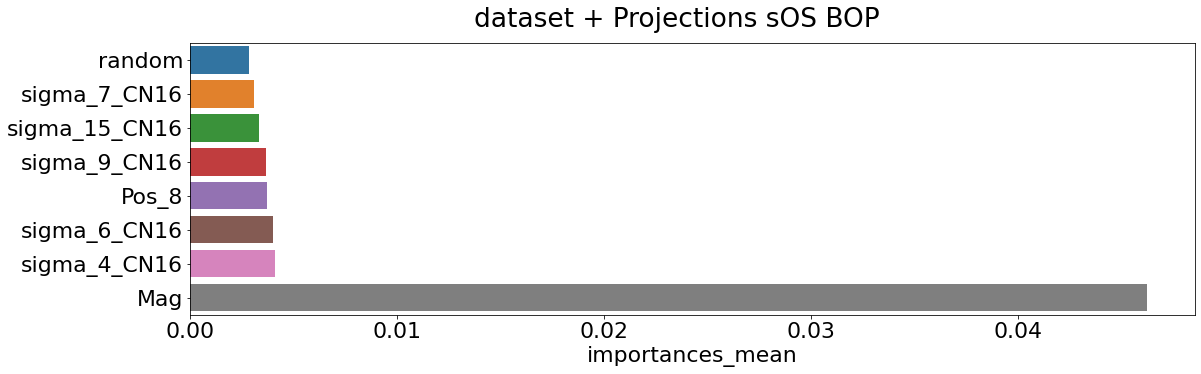

In [48]:
for (model, name), timp in importances.items():
    fig, ax = plt.subplots(figsize=(18, 0.5*len(timp)+1))
    sns.barplot(y=timp.index, x=timp['importances_mean'], ax=ax)
    fig.suptitle(name)

In [49]:
FittedWithImportantFeatures = {
    ('Kernel Ridge', 'dataset'): GridSearchCV(Models['Kernel Ridge'], Parameters['Kernel Ridge'], scoring='neg_root_mean_squared_error', cv=samplefolds).fit(DS.Features['dataset'][important_features.drop('random')], DS.target)
}

NameError: name 'important_features' is not defined

In [ ]:
FittedWithImportantFeatures[('Kernel Ridge', 'dataset')].cv_results_['mean_test_score'].max()

In [ ]:
FittedModels[('Kernel Ridge', 'dataset')].cv_results_['mean_test_score'].max()

In [ ]:
FittedWithImportantFeatures[('Kernel Ridge', 'dataset')].best_params_

In [52]:
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')

# Feature Concatenation 

In [158]:
from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcatenate', '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py').load_module().FeatureConcatenate
import warnings
warnings.filterwarnings('ignore')

In [159]:
data = pd.concat([DS.Features['Projections BOP'], DS.target], axis = 1)
feature_list = DS.Features['Projections BOP'].columns

In [160]:
FittedModels[best_combi].best_params_

{'regressor__alpha': 0.1,
 'regressor__coef0': 1,
 'regressor__degree': 5,
 'regressor__kernel': 'polynomial'}

In [161]:
param_grid = {param: [value] for param, value in FittedModels[best_combi].best_params_.items()}

In [162]:
FC = FeatureConcatenate(data, model, param_grid, feature_list=feature_list, data_target='EF', report_path=DS.dataset+'/reports/')

In [163]:
feature_list

Index(['Structure', 'Mag', 'U_bind', 'U_bond_atom_list_1_0',
       'U_bond_atom_list_1_CN12', 'U_bond_atom_list_1_CN13',
       'U_bond_atom_list_1_CN14', 'U_bond_atom_list_1_CN15',
       'U_bond_atom_list_1_CN16', 'moments_1_0',
       ...
       'Binf_1_CN14', 'Binf_1_CN15', 'Binf_1_CN16', 'sf_0', 'sf_CN12',
       'sf_CN13', 'sf_CN14', 'sf_CN15', 'sf_CN16', 'random'],
      dtype='object', length=393)

In [164]:
data.columns

Index(['Structure', 'Mag', 'U_bind', 'U_bond_atom_list_1_0',
       'U_bond_atom_list_1_CN12', 'U_bond_atom_list_1_CN13',
       'U_bond_atom_list_1_CN14', 'U_bond_atom_list_1_CN15',
       'U_bond_atom_list_1_CN16', 'moments_1_0',
       ...
       'Binf_1_CN15', 'Binf_1_CN16', 'sf_0', 'sf_CN12', 'sf_CN13', 'sf_CN14',
       'sf_CN15', 'sf_CN16', 'random', 'EF'],
      dtype='object', length=394)

In [165]:
results = FC.build_features_list(maxnumfeatures=20, best_feature_proposal=['Mag', 'Structure'])

procesing '['Mag']' with 'Structure' ... :: 100%|#########################################| 1/1 [00:00<00:00, 18.47it/s]


Refitting ..
fitting has finished,  test_score  =  0.16623156333835254


procesing '['Mag', 'Structure']' with 'bn_5_CN13' ... ::   1%|1                         | 2/339 [00:00<00:18, 17.92it/s]

Refitting ..


procesing '['Mag', 'Structure']' with 'normed_moments_6_CN16' ... :: 100%|############| 339/339 [00:17<00:00, 18.85it/s]


...

fitting has finished,  test_score  =  0.038408025112430556


procesing '['Mag', 'Structure', 'sigma_7_CN16', 'an_4_CN15', 'moments_9_CN16', 'sigma_3_CN14', 'sigma_4_CN15', 'sigma_12

Refitting ..


procesing '['Mag', 'Structure', 'sigma_7_CN16', 'an_4_CN15', 'moments_9_CN16', 'sigma_3_CN14', 'sigma_4_CN15', 'sigma_12


fitting has finished,  test_score  =  0.038922353538058126


In [170]:
len(results[0])

20

In [171]:
len(results[1])

19

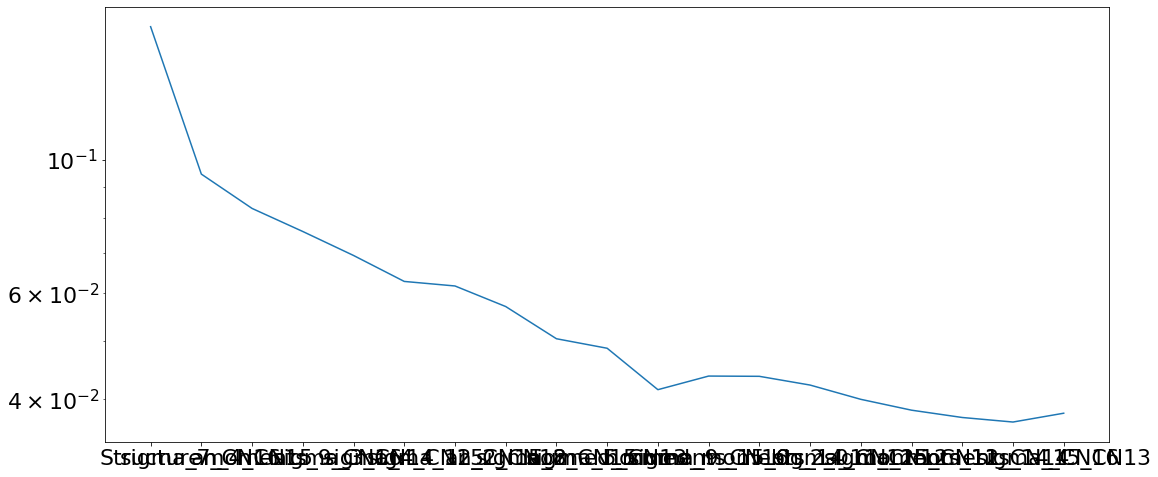

In [173]:
plt.semilogy(results[0][1:], results[1])

# only the first orders 

In [210]:
Reduced_5 = Features['Canonical BOP'].filter(regex='Structure|Mag|.*_[1-5]_.*')

In [211]:
Reduced_5.columns

Index(['Structure', 'Mag', 'U_bond_atom_list_1_0', 'U_bond_atom_list_1_CN12',
       'U_bond_atom_list_1_CN13', 'U_bond_atom_list_1_CN14',
       'U_bond_atom_list_1_CN15', 'U_bond_atom_list_1_CN16', 'moments_1_0',
       'moments_1_CN12',
       ...
       'Ainf_1_CN13', 'Ainf_1_CN14', 'Ainf_1_CN15', 'Ainf_1_CN16', 'Binf_1_0',
       'Binf_1_CN12', 'Binf_1_CN13', 'Binf_1_CN14', 'Binf_1_CN15',
       'Binf_1_CN16'],
      dtype='object', length=170)

In [ ]:
model = GridSearchCV(Models)

In [ ]:
FittedModelsReduced5 = 

# select K Best 

In [174]:
from sklearn.feature_selection import SelectKBest

In [198]:
selector = SelectKBest(k=10)

In [199]:
selector.fit(DS.Features['Projections BOP'], DS.target)

SelectKBest()

In [200]:
selector.get_feature_names_out()

array(['Binf_1_CN13', 'Binf_1_CN14', 'Binf_1_CN15', 'Binf_1_CN16', 'sf_0',
       'sf_CN12', 'sf_CN13', 'sf_CN14', 'sf_CN15', 'sf_CN16'],
      dtype=object)

In [ ]:
newmodel = Pipeline([('selector', SelectKBest(20)), ('scaler', StandardScaler())])

In [203]:
thismodel = Models['Kernel Ridge'].named_steps

In [204]:
thismodel

{'scaler': StandardScaler(),
 'regressor': KernelRidge(alpha=0.1, degree=5, kernel='polynomial')}